In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics

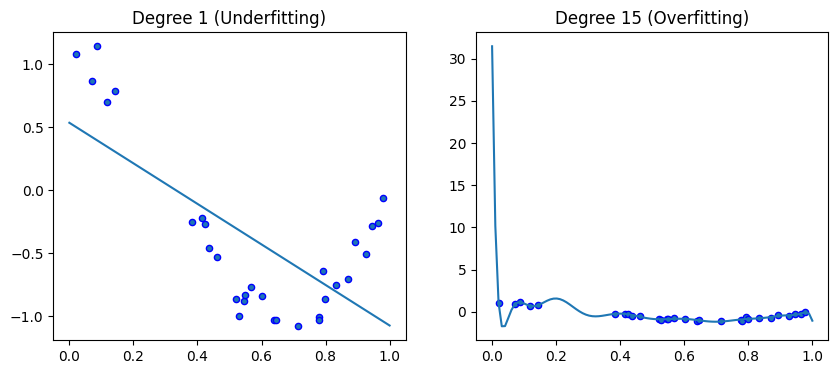

In [2]:
# ==========================================================
# 1. [과적합(Overfitting)과 과소적합(Underfitting) 개념]
# ==========================================================
# 설명: 모델이 훈련 데이터에만 너무 집착하면 과적합, 너무 단순해서 학습을 못하면 과소적합입니다.
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(10, 4))
degrees = [1, 15] # 1도(과소적합), 15도(과적합)
for i, degree in enumerate(degrees):
    ax = plt.subplot(1, 2, i + 1)
    polynomial_features = PolynomialFeatures(degree=degree, include_bias=False)
    linear_regression = LinearRegression()
    pipeline = make_pipeline(polynomial_features, linear_regression)
    pipeline.fit(X[:, np.newaxis], y)

    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.title(f"Degree {degree} ({'Underfitting' if degree==1 else 'Overfitting'})")
plt.show()

In [3]:
# ==========================================================
# 2. [정규화 기법(Regularization) 이해하기] - Ridge & Lasso
# ==========================================================
# 설명: 과적합을 막기 위해 가중치(Weight)에 패널티를 주는 기법입니다.
from sklearn.linear_model import Ridge, Lasso

# Ridge(L2 규제)와 Lasso(L1 규제) 모델 생성
ridge = Ridge(alpha=1.0) # 가중치의 제곱에 비례하는 패널티
lasso = Lasso(alpha=0.1) # 가중치의 절대값에 비례하는 패널티 (불필요한 특징 제거 효과)

In [4]:
# ==========================================================
# 3. [서포트 벡터 머신(SVM) 기초] & [그래디언트 부스팅(GBM)]
# ==========================================================
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer() # 유방암 진단 데이터 (이진 분류)
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, random_state=42)

# SVM: 데이터 사이의 최대 마진(Margin)을 찾는 분류기
#
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Gradient Boosting: 약한 모델을 순차적으로 결합하여 오차를 보완해 나가는 방식
#
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)
gb_model.fit(X_train, y_train)

print(f"SVM Accuracy: {svm_model.score(X_test, y_test):.4f}")
print(f"Gradient Boosting Accuracy: {gb_model.score(X_test, y_test):.4f}")

SVM Accuracy: 0.9580
Gradient Boosting Accuracy: 0.9580


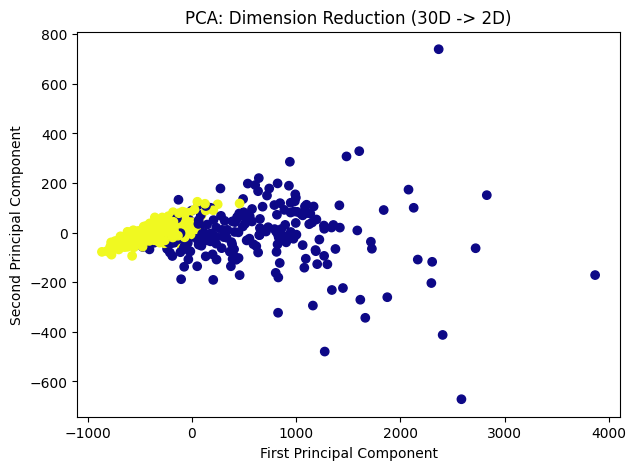

In [5]:
# ==========================================================
# 4. [주성분 분석(PCA) 개념 학습] - 비지도 학습/차원 축소
# ==========================================================
# 설명: 고차원의 데이터를 핵심 정보만 유지한 채 저차원으로 축소합니다. 시각화에 유용합니다.
from sklearn.decomposition import PCA

pca = PCA(n_components=2) # 30개의 특징을 2개로 축소
X_pca = pca.fit_transform(data.data)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data.target, cmap='plasma')
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("PCA: Dimension Reduction (30D -> 2D)")
plt.show()

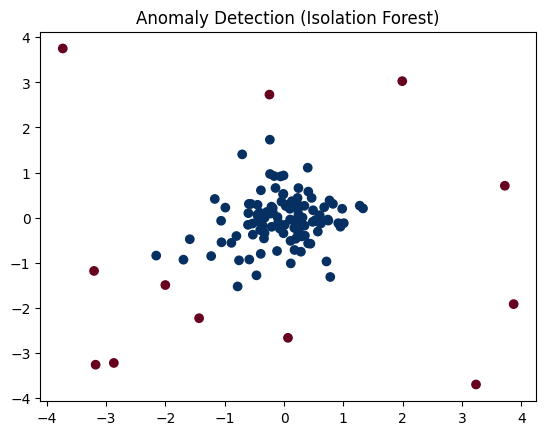

In [6]:
# ==========================================================
# 5. [이상치 탐지(Anomaly Detection) 알고리즘]
# ==========================================================
# 설명: 정상 데이터와 크게 떨어진 특이값(Outlier)을 찾아냅니다.
from sklearn.ensemble import IsolationForest

# 가상의 정상 데이터 + 이상치 생성
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X_normal = 0.5 * np.random.randn(100, 2)
X_total = np.r_[X_normal, X_outliers]

# Isolation Forest: 데이터를 고립시키는데 필요한 분할 횟수로 이상치를 판별
iso_forest = IsolationForest(contamination=0.1)
y_pred = iso_forest.fit_predict(X_total) # -1이면 이상치, 1이면 정상

plt.scatter(X_total[:, 0], X_total[:, 1], c=y_pred, cmap='RdBu')
plt.title("Anomaly Detection (Isolation Forest)")
plt.show()